# Feed-Forward Neural Network for Affordability Percent Change

This notebook follows `neural_network_affordability.ipynb`, but predicts the affordability percent-change column instead of the affordability score.

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import keras
import tensorflow as tf
from tensorflow.keras import layers

In [18]:
df = pd.read_csv('../data/processed/final_3d_df_with_rolling_averages.csv')


In [19]:
lag_features = [col for col in df.columns if 'prev_mo' in col]
rolling_features = [col for col in df.columns if 'rolling' in col]
feature_columns = lag_features + rolling_features

# FIPS is categorical. One-hot encode it and never use the raw FIPS number as a numeric feature.
fips_encoded = pd.get_dummies(df['fips'].astype(str), prefix='fips', drop_first=True)


# Prepare X and y
X_feature = df[feature_columns].values
y = df['county_perc_mo'].values


In [20]:
scaler = StandardScaler()
X_feature_scaled = scaler.fit_transform(X_feature)
X = np.column_stack([X_feature_scaled, fips_encoded.values])


In [21]:
split_year = 2020

train_mask = df['year'] <= split_year
test_mask = df['year'] > split_year


X_train = X[train_mask.values]
y_train = y[train_mask.values]
X_test = X[test_mask.values]
y_test = y[test_mask.values]


In [22]:
input_size = X_train.shape[1]

# Improved architecture: deeper network with regularization and batch normalization
model = keras.Sequential([
    layers.Dense(128, activation='relu', input_shape=(input_size,), kernel_regularizer=keras.regularizers.l2(0.001)),
    layers.BatchNormalization(),
    layers.Dropout(0.3),
    layers.Dense(64, activation='relu', kernel_regularizer=keras.regularizers.l2(0.001)),
    layers.BatchNormalization(),
    layers.Dropout(0.3),
    layers.Dense(32, activation='relu', kernel_regularizer=keras.regularizers.l2(0.001)),
    layers.BatchNormalization(),
    layers.Dropout(0.2),
    layers.Dense(16, activation='relu'),
    layers.Dropout(0.1),
    layers.Dense(1)
])

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.0008),
    loss='huber', 
    # More robust to outliers
    metrics=['mae']
)
model.summary()

/Users/luke/Desktop/Affordable-housing-final/.venv/lib/python3.11/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 128)            │       203,008 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 214,785 (839.00 KB)

 Trainable params: 214,337 (837.25 KB)

 Non-trainable params: 448 (1.75 KB)

In [23]:
history = model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=128,
    validation_data=(X_test, y_test),
    verbose=1,
    shuffle=True,
    callbacks=[
        keras.callbacks.EarlyStopping(
            monitor='val_loss',
            patience=8,
            restore_best_weights=True
        ),
        keras.callbacks.ReduceLROnPlateau(
            monitor='val_loss',
            factor=0.5,
            patience=4,
            min_lr=0.00001,
            verbose=1
        )
    ]
)

Epoch 1/50
2300/2300 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - loss: 0.0989 - mae: 0.1024 - val_loss: 0.0096 - val_mae: 0.0394 - learning_rate: 8.0000e-04
Epoch 2/50
2300/2300 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - loss: 0.0047 - mae: 0.0325 - val_loss: 0.0018 - val_mae: 0.0193 - learning_rate: 8.0000e-04
Epoch 3/50
2300/2300 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - loss: 0.0031 - mae: 0.0288 - val_loss: 0.0030 - val_mae: 0.0389 - learning_rate: 8.0000e-04
Epoch 4/50
2300/2300 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - loss: 0.0029 - mae: 0.0282 - val_loss: 0.0016 - val_mae: 0.0207 - learning_rate: 8.0000e-04
Epoch 5/50
2300/2300 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - loss: 0.0028 - mae: 0.0284 - val_loss: 0.0017 - val_mae: 0.0338 - learning_rate: 8.0000e-04
Epoch 6/50
2300/2300 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - loss: 0.0026 - mae: 0.0280 - val_loss: 0.0019 - val_mae: 0.0307 - learning_rate: 8.0000e-04
Epoch 7/50
2300/2300 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - loss: 0.0025 - mae: 0.0279 - val_loss: 0.0032 - val_mae:

In [24]:
y_train_pred = model.predict(X_train, verbose=0)
y_test_pred = model.predict(X_test, verbose=0)


train_mse = mean_squared_error(y_train, y_train_pred)
test_mse = mean_squared_error(y_test, y_test_pred)
train_rmse = np.sqrt(train_mse)
test_rmse = np.sqrt(test_mse)
train_mae = mean_absolute_error(y_train, y_train_pred)
test_mae = mean_absolute_error(y_test, y_test_pred)
train_r2 = r2_score(y_train, y_train_pred)
test_r2 = r2_score(y_test, y_test_pred)


print("Train Set:")
print(f"MSE: {train_mse:.6f}")
print(f"RMSE: {train_rmse:.6f}")
print(f"MAE: {train_mae:.6f}")
print(f"R²: {train_r2:.6f}")

print("Test Set:")
print(f"MSE: {test_mse:.6f}")
print(f"RMSE: {test_rmse:.6f}")
print(f"MAE: {test_mae:.6f}")
print(f"R²: {test_r2:.6f}")


Train Set:
MSE: 0.002272
RMSE: 0.047665
MAE: 0.017922
R²: 0.925072
Test Set:
MSE: 0.001020
RMSE: 0.031943
MAE: 0.019599
R²: 0.950942


/var/folders/p0/2s52s_cn2bb70073yy5f_z_c0000gn/T/ipykernel_35496/4128088050.py:19: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[1].legend()


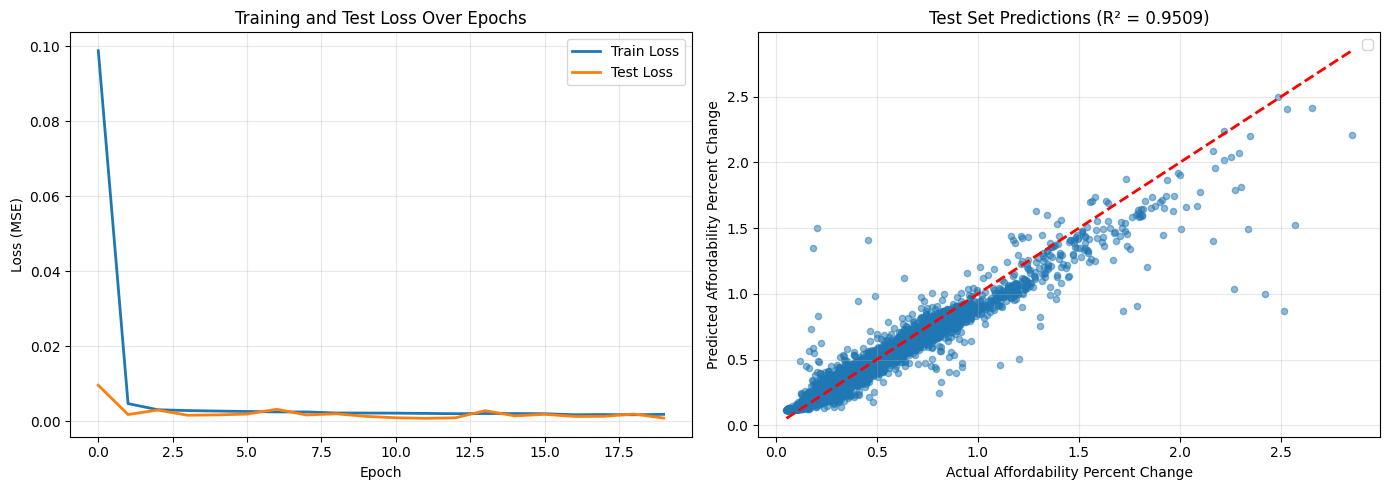

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history.history['loss'], label='Train Loss', linewidth=2)
axes[0].plot(history.history['val_loss'], label='Test Loss', linewidth=2)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss (MSE)')
axes[0].set_title('Training and Test Loss Over Epochs')
axes[0].legend()
axes[0].grid(True, alpha=0.3)


axes[1].scatter(y_test, y_test_pred, alpha=0.5, s=20)
min_val = min(y_test.min(), y_test_pred.min())
max_val = max(y_test.max(), y_test_pred.max())
axes[1].plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2)
axes[1].set_xlabel('Actual Affordability Percent Change')
axes[1].set_ylabel('Predicted Affordability Percent Change')
axes[1].set_title(f'Test Set Predictions (R² = {test_r2:.4f})')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


/var/folders/p0/2s52s_cn2bb70073yy5f_z_c0000gn/T/ipykernel_35496/100798201.py:32: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1, 1].boxplot([y_train - y_train_pred.flatten(), residuals], labels=['Train', 'Test'])


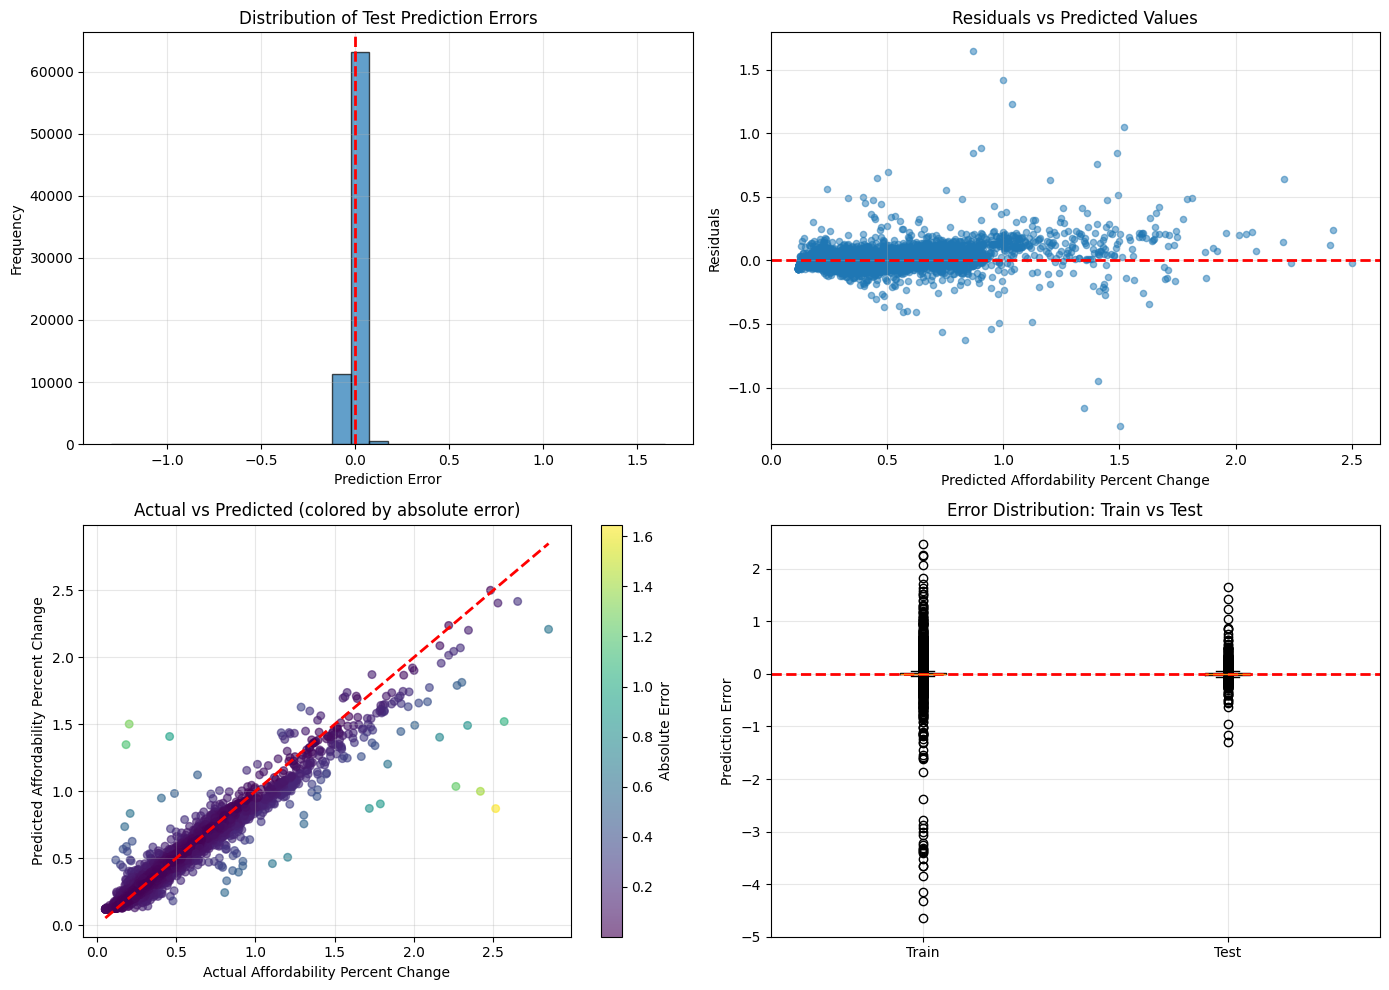


Error Statistics:
Mean Error: 0.001349
Std Error: 0.031914
Min Error: -1.298131
Max Error: 1.646221


In [26]:

# Additional analysis: error distribution
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Residuals plot
residuals = y_test - y_test_pred.flatten()
axes[0, 0].hist(residuals, bins=30, edgecolor='black', alpha=0.7)
axes[0, 0].set_xlabel('Prediction Error')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].set_title('Distribution of Test Prediction Errors')
axes[0, 0].axvline(x=0, color='r', linestyle='--', linewidth=2)
axes[0, 0].grid(True, alpha=0.3)

# Residuals vs predicted
axes[0, 1].scatter(y_test_pred, residuals, alpha=0.5, s=20)
axes[0, 1].axhline(y=0, color='r', linestyle='--', linewidth=2)
axes[0, 1].set_xlabel('Predicted Affordability Percent Change')
axes[0, 1].set_ylabel('Residuals')
axes[0, 1].set_title('Residuals vs Predicted Values')
axes[0, 1].grid(True, alpha=0.3)

# Actual vs Predicted scatter with color gradient by error
errors = np.abs(residuals)
scatter = axes[1, 0].scatter(y_test, y_test_pred, c=errors, cmap='viridis', alpha=0.6, s=30)
axes[1, 0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', linewidth=2)
axes[1, 0].set_xlabel('Actual Affordability Percent Change')
axes[1, 0].set_ylabel('Predicted Affordability Percent Change')
axes[1, 0].set_title('Actual vs Predicted (colored by absolute error)')
plt.colorbar(scatter, ax=axes[1, 0], label='Absolute Error')
axes[1, 0].grid(True, alpha=0.3)

# Error by quantile
axes[1, 1].boxplot([y_train - y_train_pred.flatten(), residuals], labels=['Train', 'Test'])
axes[1, 1].set_ylabel('Prediction Error')
axes[1, 1].set_title('Error Distribution: Train vs Test')
axes[1, 1].axhline(y=0, color='r', linestyle='--', linewidth=2)
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nError Statistics:")
print(f"Mean Error: {np.mean(residuals):.6f}")
print(f"Std Error: {np.std(residuals):.6f}")
print(f"Min Error: {np.min(residuals):.6f}")
print(f"Max Error: {np.max(residuals):.6f}")
